# Nearest- and next-nearest-neighbor Kagome tight-binding bands

The three-site unit cell is taken as
$\mathbf r_A=(0,0)$, $\mathbf r_B=(L,0)$, and
$\mathbf r_C=(L/2,\sqrt{3}L/2)$. Nearest-neighbor (NN) sites are
separated by $L$, while next-nearest-neighbor (NNN) sites in the
geometrical second shell are separated by $\sqrt{3}L$. The model is

$$
\hat H=-t\sum_{\langle m,n\rangle}c_m^\dagger c_n
-t'\sum_{\langle\!\langle m,n\rangle\!\rangle}c_m^\dagger c_n
+\mathrm{h.c.}
$$

and its Bloch matrix is

$$
H(\mathbf k)=-\begin{pmatrix}
0 & \gamma_{AB} & \gamma_{AC}\\
\gamma_{AB}^* & 0 & \gamma_{BC}\\
\gamma_{AC}^* & \gamma_{BC}^* & 0
\end{pmatrix}.
$$

$$
\begin{aligned}
\gamma_{AB}={}&t(e^{ik_xL}+e^{-ik_xL})
+t'(e^{i\sqrt3k_yL}+e^{-i\sqrt3k_yL}),\\
\gamma_{AC}={}&t(e^{iL(k_x+\sqrt3k_y)/2}+e^{-iL(k_x+\sqrt3k_y)/2})\\
&+t'(e^{iL(-3k_x+\sqrt3k_y)/2}+e^{-iL(-3k_x+\sqrt3k_y)/2}),\\
\gamma_{BC}={}&t(e^{iL(-k_x+\sqrt3k_y)/2}+e^{-iL(-k_x+\sqrt3k_y)/2})\\
&+t'(e^{iL(3k_x+\sqrt3k_y)/2}+e^{-iL(3k_x+\sqrt3k_y)/2}).
\end{aligned}
$$


In [50]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams


In [51]:
# Model and plot settings
L = 1.0
t = 1.0
t_prime = 0.1 * t
POINTS_PER_UNIT = 200

SHOW_PLOT_DECORATIONS = True
SAVE_PLOT = False
OUTPUT_FILE = Path('../../../output/paper_upload/kagome_TB_NNN_comparison.pdf')


## Solve along $\Gamma$–K–M–$\Gamma$


In [52]:
def kagome_hamiltonian(k_x, k_y, L=1.0, t=1.0, t_prime=0.0):
    """Return the 3x3 Kagome Bloch Hamiltonian with NN and NNN hopping."""
    phi_ab_nn = k_x * L
    phi_ac_nn = (k_x + np.sqrt(3) * k_y) * L / 2
    phi_bc_nn = (-k_x + np.sqrt(3) * k_y) * L / 2

    phi_ab_nnn = np.sqrt(3) * k_y * L
    phi_ac_nnn = (-3 * k_x + np.sqrt(3) * k_y) * L / 2
    phi_bc_nnn = (3 * k_x + np.sqrt(3) * k_y) * L / 2

    hop_ab = (
        t * (np.exp(1j * phi_ab_nn) + np.exp(-1j * phi_ab_nn))
        + t_prime * (np.exp(1j * phi_ab_nnn) + np.exp(-1j * phi_ab_nnn))
    )
    hop_ac = (
        t * (np.exp(1j * phi_ac_nn) + np.exp(-1j * phi_ac_nn))
        + t_prime * (np.exp(1j * phi_ac_nnn) + np.exp(-1j * phi_ac_nnn))
    )
    hop_bc = (
        t * (np.exp(1j * phi_bc_nn) + np.exp(-1j * phi_bc_nn))
        + t_prime * (np.exp(1j * phi_bc_nnn) + np.exp(-1j * phi_bc_nnn))
    )

    return -np.array([
        [0, hop_ab, hop_ac],
        [np.conj(hop_ab), 0, hop_bc],
        [np.conj(hop_ac), np.conj(hop_bc), 0],
    ], dtype=complex)


In [53]:
# High-symmetry points for a Kagome lattice with nearest-neighbor spacing L.
Gamma = np.array([0.0, 0.0])
K = np.array([2 * np.pi / (3 * L), 0.0])
M = np.array([np.pi / (2 * L), np.pi / (2 * np.sqrt(3) * L)])

k_nodes = [Gamma, K, M, Gamma]
s_nodes = np.array([0.0, 1.0, 1.5, 2.5])

sweep_coordinate = []
k_sweep = []
for segment_index, (k_start, k_stop) in enumerate(zip(k_nodes[:-1], k_nodes[1:])):
    s_start, s_stop = s_nodes[segment_index:segment_index + 2]
    number_of_points = round(POINTS_PER_UNIT * (s_stop - s_start)) + 1
    segment_s = np.linspace(s_start, s_stop, number_of_points)
    segment_k = np.linspace(k_start, k_stop, number_of_points)
    if segment_index:
        segment_s = segment_s[1:]
        segment_k = segment_k[1:]
    sweep_coordinate.extend(segment_s)
    k_sweep.extend(segment_k)

sweep_coordinate = np.asarray(sweep_coordinate)
k_sweep = np.asarray(k_sweep)
def solve_sweep(t_prime_value):
    return np.stack([
        np.linalg.eigvalsh(
            kagome_hamiltonian(k_x, k_y, L=L, t=t, t_prime=t_prime_value)
        )
        for k_x, k_y in k_sweep
    ], axis=1)


bands_nn = solve_sweep(t_prime_value=0.0)
bands_nnn = solve_sweep(t_prime_value=t_prime)
assert np.allclose(bands_nn[-1], 2 * t)


## Flat-band energy and bandwidth

The upper band is the exactly flat band when $t'=0$ and the band continuously
connected to it when $t'\ne0$. For the broadened band, its representative
energy is defined as $(E_{\min}+E_{\max})/2$ and its bandwidth as
$E_{\max}-E_{\min}$. The extrema below are evaluated over the plotted
$\Gamma$–K–M–$\Gamma$ sweep.


In [54]:
def flat_band_statistics(solved_bands):
    upper_band = solved_bands[-1]
    energy_min = np.min(upper_band)
    energy_max = np.max(upper_band)
    return {
        'energy': (energy_min + energy_max) / 2,
        'minimum': energy_min,
        'maximum': energy_max,
        'width': energy_max - energy_min,
    }


flat_band_results = {
    'NN only': flat_band_statistics(bands_nn),
    f"NN + NNN (t'/t = {t_prime / t:g})": flat_band_statistics(bands_nnn),
}

print(f"{'model':<24} {'energy/t':>12} {'min/t':>12} {'max/t':>12} {'width/t':>12}")
for model_name, result in flat_band_results.items():
    print(
        f"{model_name:<24} {result['energy'] / t:12.6f} "
        f"{result['minimum'] / t:12.6f} {result['maximum'] / t:12.6f} "
        f"{result['width'] / t:12.6f}"
    )

nn_result = flat_band_results['NN only']
nnn_result = flat_band_results[f"NN + NNN (t'/t = {t_prime / t:g})"]
print(f"\nCenter-energy shift: {(nnn_result['energy'] - nn_result['energy']) / t:.6f} t")
print(f"Bandwidth increase: {(nnn_result['width'] - nn_result['width']) / t:.6f} t")


model                        energy/t        min/t        max/t      width/t
NN only                      2.000000     2.000000     2.000000     0.000000
NN + NNN (t'/t = 0.1)        1.900000     1.600000     2.200000     0.600000

Center-energy shift: -0.100000 t
Bandwidth increase: 0.600000 t


## Plot in the Fig. 1 style


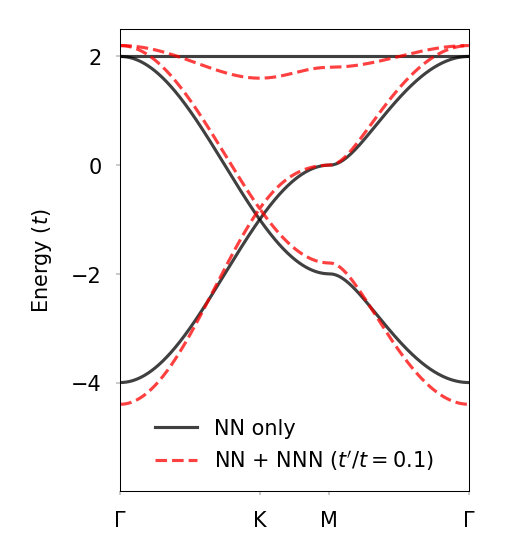

In [55]:
rcParams.update({
    'font.size': 5,
    'axes.labelsize': 5,
    'xtick.labelsize': 5,
    'ytick.labelsize': 5,
})

fig, ax = plt.subplots(figsize=(1.5, 2), dpi=300)
ax.set_xlim(s_nodes[0], s_nodes[-1])
ax.set_ylim(-6, 2.5)

for spine in ax.spines.values():
    spine.set_linewidth(0.25)

ax.set_xticks(s_nodes, [r'$\Gamma$', 'K', 'M', r'$\Gamma$'])
ax.set_yticks(np.linspace(-4, 2, 4, endpoint=True))
ax.xaxis.set_tick_params(width=0.1, length=1)
ax.yaxis.set_tick_params(width=0.1, length=1)

if SHOW_PLOT_DECORATIONS:
    ax.set_ylabel(r'Energy ($t$)')
else:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)

for band_index, band in enumerate(bands_nn):
    ax.plot(
        sweep_coordinate, band / t, 'k-', linewidth=0.75, alpha=0.75,
        label='NN only' if band_index == 0 else None,
    )

for band_index, band in enumerate(bands_nnn):
    ax.plot(
        sweep_coordinate, band / t, color='red', linestyle='--',
        linewidth=0.75, alpha=0.75,
        label=rf"NN + NNN ($t'/t={t_prime / t:g}$)" if band_index == 0 else None,
    )

if SHOW_PLOT_DECORATIONS:
    ax.legend(loc='lower center', frameon=False)

if SAVE_PLOT:
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_FILE)

plt.show()


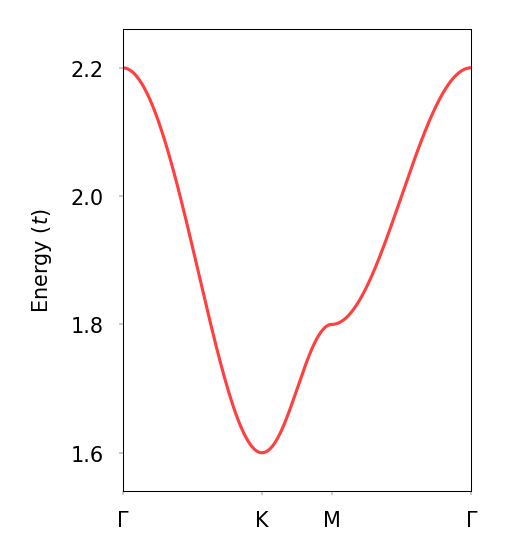

In [56]:
# Plot only the upper band of the NN + NNN model with a tight energy scale.
flat_band_nnn = bands_nnn[-1] / t
flat_band_width = np.ptp(flat_band_nnn)
energy_margin = 0.1 * flat_band_width if flat_band_width > 0 else 0.1

flat_fig, flat_ax = plt.subplots(figsize=(1.5, 2), dpi=300)
flat_ax.set_xlim(s_nodes[0], s_nodes[-1])
flat_ax.set_ylim(
    flat_band_nnn.min() - energy_margin,
    flat_band_nnn.max() + energy_margin,
)

for spine in flat_ax.spines.values():
    spine.set_linewidth(0.25)

flat_ax.set_xticks(s_nodes, [r'$\Gamma$', 'K', 'M', r'$\Gamma$'])
flat_ax.set_yticks(np.linspace(flat_band_nnn.min(), flat_band_nnn.max(), 4))
flat_ax.xaxis.set_tick_params(width=0.1, length=1)
flat_ax.yaxis.set_tick_params(width=0.1, length=1)

if SHOW_PLOT_DECORATIONS:
    flat_ax.set_ylabel(r'Energy ($t$)')
else:
    flat_ax.set_xlabel('')
    flat_ax.set_ylabel('')
    flat_ax.set_title('')
    flat_ax.tick_params(axis='x', labelbottom=False)
    flat_ax.tick_params(axis='y', labelleft=False)

flat_ax.plot(
    sweep_coordinate, flat_band_nnn,
    color='red', linewidth=0.75, alpha=0.75,
)

if SAVE_PLOT:
    flat_band_output = OUTPUT_FILE.with_name('kagome_TB_NNN_flat_band.pdf')
    flat_band_output.parent.mkdir(parents=True, exist_ok=True)
    flat_fig.savefig(flat_band_output)

plt.show()


## Estimate the hoppings from COMSOL spectral features

Following `fig1_shb.ipynb`, the lowest three sorted bands are extracted
from `extkag_0_extremelyfine_shb.csv`. The 48 COMSOL sweep points are
mapped to the $\Gamma$–K–M–$\Gamma$ path with the same geometrical
sampling helper used in that notebook.

Instead of a global least-squares fit, use the dispersive-band opening at
M and the upper-band width:

$$
\Delta_M=f_2(\mathrm M)-f_1(\mathrm M)=2(t-t'),\qquad
W_{\mathrm{flat}}=\max_{\mathbf k}f_3-\min_{\mathbf k}f_3=6t'.
$$

Therefore $t'=W_{\mathrm{flat}}/6$ and
$t=\Delta_M/2+t'$. Both hoppings are estimated in kHz. For the overlay,
the frequency offset $f_0$ is fixed by the middle dispersive band at M,
whose tight-binding eigenvalue is zero.


In [57]:
import sys

paper_figure_directory = Path('../paper_fig_upload').resolve()
if str(paper_figure_directory) not in sys.path:
    sys.path.insert(0, str(paper_figure_directory))

from defs import (
    band_frequency_matrix,
    extract_band_structure,
    generate_k_space_sweep,
)


In [58]:
comsol_file = Path('../../../data/simulation/extkag_0_extremelyfine_shb.csv')
comsol_dataset = extract_band_structure(comsol_file, max_bands=3)
b_comsol = np.asarray(list(comsol_dataset['frequencies_by_b_hz']))
bands_comsol_khz = band_frequency_matrix(comsol_dataset).T / 1e3

_, kx_fit, ky_fit = generate_k_space_sweep(
    [Gamma, K, M, Gamma], num_points=len(b_comsol)
)
assert len(kx_fit) == len(b_comsol)

print(f'Loaded {bands_comsol_khz.shape[0]} bands at {len(b_comsol)} sweep points')
print(f'COMSOL sweep range: b = {b_comsol[0]:g} to {b_comsol[-1]:g}')


Loaded 3 bands at 48 sweep points
COMSOL sweep range: b = 0 to 2.35


In [59]:
def estimated_bands_khz(frequency_offset_khz, hopping_t_khz, hopping_t_prime_khz):
    return np.stack([
        frequency_offset_khz + np.linalg.eigvalsh(
            kagome_hamiltonian(
                k_x, k_y, L=L, t=hopping_t_khz,
                t_prime=hopping_t_prime_khz,
            )
        )
        for k_x, k_y in zip(kx_fit, ky_fit)
    ], axis=1)


m_index = np.argmin(np.abs(b_comsol - 1.5))
if not np.isclose(b_comsol[m_index], 1.5):
    raise ValueError('The COMSOL sweep does not contain the M point at b = 1.5')

dispersive_opening_khz = (
    bands_comsol_khz[1, m_index] - bands_comsol_khz[0, m_index]
)
flat_band_comsol_khz = bands_comsol_khz[-1]
flat_band_min_khz = np.min(flat_band_comsol_khz)
flat_band_max_khz = np.max(flat_band_comsol_khz)
flat_band_width_khz = flat_band_max_khz - flat_band_min_khz

t_prime_estimate_khz = flat_band_width_khz / 6
t_estimate_khz = dispersive_opening_khz / 2 + t_prime_estimate_khz
t_prime_over_t = t_prime_estimate_khz / t_estimate_khz
t_over_t_prime = t_estimate_khz / t_prime_estimate_khz

# At M, the middle tight-binding eigenvalue is zero.
frequency_offset_estimate_khz = bands_comsol_khz[1, m_index]
bands_estimated_khz = estimated_bands_khz(
    frequency_offset_estimate_khz, t_estimate_khz, t_prime_estimate_khz
)
estimate_residuals_khz = bands_estimated_khz - bands_comsol_khz
estimate_rmse_khz = np.sqrt(np.mean(estimate_residuals_khz**2))

print(f'M-point dispersive opening = {dispersive_opening_khz:.6f} kHz')
print(
    f'Flat-band range = {flat_band_min_khz:.6f} to '
    f'{flat_band_max_khz:.6f} kHz'
)
print(f'Flat-band width = {flat_band_width_khz:.6f} kHz')
print(f't  = {t_estimate_khz:.6f} kHz')
print(f"t' = {t_prime_estimate_khz:.6f} kHz")
print(f"t'/t = {t_prime_over_t:.6f}")
print(f"t/t' = {t_over_t_prime:.6f}")
print(f'f0 (anchored at M) = {frequency_offset_estimate_khz:.6f} kHz')
print(f'Overlay RMSE = {estimate_rmse_khz:.6f} kHz')


M-point dispersive opening = 3.476144 kHz
Flat-band range = 14.205312 to 14.499561 kHz
Flat-band width = 0.294249 kHz
t  = 1.787114 kHz
t' = 0.049042 kHz
t'/t = 0.027442
t/t' = 36.440803
f0 (anchored at M) = 10.562369 kHz
Overlay RMSE = 0.676686 kHz


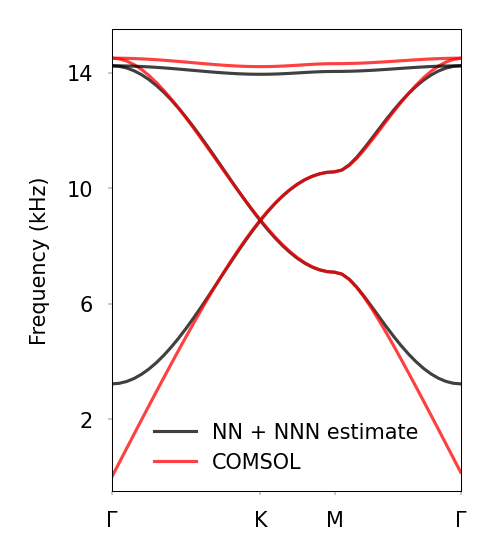

In [60]:
fit_fig, fit_ax = plt.subplots(figsize=(1.5, 2), dpi=300)
fit_ax.set_xlim(b_comsol[0], b_comsol[-1])
fit_ax.set_ylim(-0.5, 15.5)

for spine in fit_ax.spines.values():
    spine.set_linewidth(0.25)

fit_ax.set_xticks(
    [0, 1, 1.5, b_comsol[-1]],
    [r'$\Gamma$', 'K', 'M', r'$\Gamma$'],
)
fit_ax.set_yticks(np.linspace(2, 14, 4, endpoint=True))
fit_ax.xaxis.set_tick_params(width=0.1, length=1)
fit_ax.yaxis.set_tick_params(width=0.1, length=1)

if SHOW_PLOT_DECORATIONS:
    fit_ax.set_ylabel('Frequency (kHz)')
else:
    fit_ax.set_xlabel('')
    fit_ax.set_ylabel('')
    fit_ax.set_title('')
    fit_ax.tick_params(axis='x', labelbottom=False)
    fit_ax.tick_params(axis='y', labelleft=False)

for band_index in range(3):
    fit_ax.plot(
        b_comsol, bands_estimated_khz[band_index],
        'k-', linewidth=0.75, alpha=0.75,
        label='NN + NNN estimate' if band_index == 0 else None,
    )
    fit_ax.plot(
        b_comsol, bands_comsol_khz[band_index],
        'r-', linewidth=0.75, alpha=0.75,
        label='COMSOL' if band_index == 0 else None,
    )

if SHOW_PLOT_DECORATIONS:
    fit_ax.legend(loc='lower center', frameon=False)

if SAVE_PLOT:
    estimate_output = OUTPUT_FILE.with_name('kagome_TB_COMSOL_estimate.pdf')
    estimate_output.parent.mkdir(parents=True, exist_ok=True)
    fit_fig.savefig(estimate_output)

plt.show()
